# Price distribution: mean vs. median vs. mode

MIMIT publishes a national daily average price per fuel type as a "fair price" reference. This notebook checks whether that average is actually representative, or whether the distribution is skewed enough that the mean gets pulled away from what most stations are actually charging.

Approach: start with a single day's snapshot of prices for one fuel type / self-service value across all stations (mirroring how the published national average is computed) and compare mean, median, and mode; then repeat the measurement monthly across the whole dataset to see whether that verdict holds over time.

**Finding (Benzina, self-service, 2026-08-20):** mean 2.003, median 1.999, mode 2.00 - essentially no skew at all. An earlier pass of this analysis found a left-skewed distribution (mean well below median/mode), which turned out to be a data-quality artifact, not a real pricing pattern - see the data-quality section below. Once that's corrected, the published average genuinely does look representative of what most stations charge for Benzina self-service.

**Finding (over time, 2015-2026):** the same holds across the whole series - mean and median stay within ~1 cent/L of each other in normal conditions. The only meaningful skew appears in the weeks around a price shock (COVID crash, Ukraine invasion), and it is transient. The more interesting question becomes what explains the *spread* around the central number (the std is still 0.05, i.e. a few cents either way) - that's the subject of the next notebook (price drivers).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from app.services.mirror import Mirror

# Query the read-only DuckDB mirror, not the live Postgres DB. The mirror
# exposes the same forward-fill semantics as the app's prices_daily() via the
# prices_daily_mirror(start_date, end_date) table macro, plus mirrored
# `station` and `price_change` tables.
con = Mirror().connect(read_only=True)
con.execute("SET enable_progress_bar = false")  # keep notebook outputs clean

## Pick a snapshot date

Data currently runs through 2026-08-20. We use the mirror's `prices_daily_mirror(start, end)` table macro (which applies the same forward-fill and `max_extraction_date` cutoff as the app's `prices_daily()`) so we get one row per station per fuel/self-service combination as of a given day, rather than raw change-history rows.

In [2]:
SNAPSHOT_DATE = '2026-08-20'
FUEL = 'Benzina'
SELF_SERVICE = True

query = """
    SELECT station_id, price
    FROM prices_daily_mirror(?, ?)
    WHERE fuel_description = ? AND self_service = ?
"""

df = con.execute(query, [SNAPSHOT_DATE, SNAPSHOT_DATE, FUEL, SELF_SERVICE]).df()
df['price'] = df['price'].astype(float)
len(df)

20295

## Data quality: stale/closed stations

`prices_daily()` forward-fills each station's last known price onto every later calendar day, with no cutoff - so a station that stopped appearing in the scraped files entirely (very likely closed - confirmed separately that ~46.5% of all 48,949 stations ever seen haven't been seen in over a year) still showed up as if it had a valid, current price, sometimes carried forward from a price last confirmed in **2014-2018**. This inflated the earlier snapshot to ~38,700 rows and produced a spurious "discount cluster" that pulled the mean well below the median/mode.

Fixed at the source (migration `8b33433721cf`): `prices_daily()` now requires the forward-filled row's `max_extraction_date` (which `ingest_df` widens on every re-confirmation of an unchanged price, so it freezes the moment a station drops out of the files) to actually cover the requested date. The snapshot below is now 20,295 rows, all with genuinely recent `entry_date`s.

A handful of literal `0.00` prices can still slip through (11 out of the old 38,700-row snapshot) - not a real price, so still worth an explicit guard here even though the DB-level fix removes the bulk of the problem.

In [3]:
n_before = len(df)
df = df[df['price'] > 0]
print(f"dropped {n_before - len(df)} non-physical (<= 0) price rows")

dropped 0 non-physical (<= 0) price rows


## Central tendency

Mode needs binning: raw prices are quoted to the nearest tenth of a cent, so a literal `.mode()` over floats is nearly meaningless (most values are unique). Bin to the nearest whole cent, which is how prices are actually displayed/compared at the pump.

In [5]:
mean_price = df['price'].mean()
median_price = df['price'].median()

binned = (df['price'] * 100).round().astype(int) / 100
mode_price = binned.mode().iloc[0]

print(f"mean:   {mean_price:.3f}")
print(f"median: {median_price:.3f}")
print(f"mode:   {mode_price:.3f}  (binned to nearest cent)")

mean:   2.003
median: 1.999
mode:   2.000  (binned to nearest cent)
mean:   2.018
median: 2.019
mode:   2.000  (binned to nearest cent)


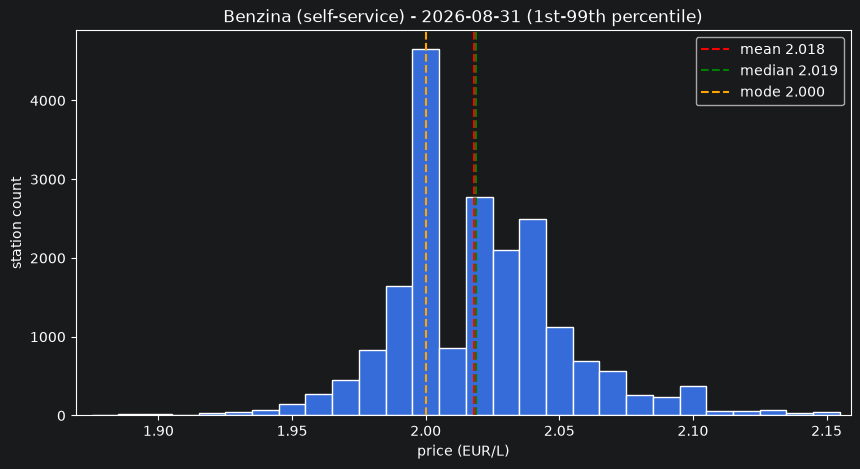

In [6]:
# Prices are tightly clustered (25th-75th percentile is only 1.989-2.019)
# with a long thin tail out to 3.978, so a fixed-range histogram mostly shows
# empty bins. Zoom to the 1st-99th percentile range and bin by whole cents,
# which is the real resolution these prices are quoted/compared at.
lo, hi = df['price'].quantile([0.01, 0.99])
bin_edges = pd.interval_range(start=round(lo, 2) - 0.005, end=round(hi, 2) + 0.005, freq=0.01).left.tolist() + [round(hi, 2) + 0.005]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['price'], bins=bin_edges, edgecolor='white')
ax.axvline(mean_price, color='red', linestyle='--', label=f'mean {mean_price:.3f}')
ax.axvline(median_price, color='green', linestyle='--', label=f'median {median_price:.3f}')
ax.axvline(mode_price, color='orange', linestyle='--', label=f'mode {mode_price:.3f}')
ax.set_xlim(lo - 0.01, hi + 0.01)
ax.set_xlabel('price (EUR/L)')
ax.set_ylabel('station count')
ax.set_title(f'{FUEL} ({"self-service" if SELF_SERVICE else "full-service"}) - {SNAPSHOT_DATE} (1st-99th percentile)')
ax.legend()
plt.show()

## Sanity checks

- Row count should roughly match the known station population for this fuel/service combination - implausibly low counts likely mean the snapshot date isn't fully loaded yet.
- Compare `mean_price` against MIMIT's own published national average for the same date/fuel to confirm we're querying the same population they are.
- Look for absurd outliers (near-zero or very high prices) - these are a data-quality signal, not necessarily something to filter silently.

In [7]:
df['price'].describe()

count    20279.000000
mean         2.017958
std          0.050701
min          1.499000
25%          1.999000
50%          2.019000
75%          2.039000
max          2.763000
Name: price, dtype: float64

In [7]:
df.sort_values('price').head(10)

,station_id,price
5606,33045,1.209
20211,52119,1.499
14072,51363,1.513
14869,21866,1.518
14867,21869,1.518
105,24309,1.527
11925,22670,1.528
18541,51364,1.529
11930,22687,1.529
11929,22628,1.530


In [8]:
df.sort_values('price').tail(10)

,station_id,price
3604,61730,2.499
16981,61729,2.499
12906,33726,2.500
67,3927,2.550
5600,25821,2.565
8247,61198,2.689
10374,61542,2.689
1990,12654,2.740
17500,61340,2.763
10031,60232,3.978


## How the distribution moves over time

The section above is a single day's snapshot. To check whether the mean stays
representative across the *whole* dataset (2015-01 to 2026-08), we repeat the
same measurement monthly: every active price for the chosen fuel / self-service
value on the 15th of each month, summarised as mean, median and mode (binned to
the nearest cent, as before) plus the interquartile range.

DuckDB does the aggregation - a single pass over the 128M-row `price_change`
table, joining each monthly sample date against the row's
`[min_extraction_date, max_extraction_date]` span (the same forward-fill-with-
cutoff rule `prices_daily_mirror` applies, so each month counts only stations
genuinely active then). Pulling the raw rows into pandas for this would be
hopeless; the aggregate returns in a few seconds.

In [8]:
ts_query = """
WITH sample_days AS (
    SELECT unnest(generate_series(DATE '2015-01-01', DATE '2026-09-01', INTERVAL 1 month))::date AS d
)
SELECT
    s.d                                    AS month,
    count(*)                               AS n_stations,
    avg(pc.price)::double                  AS mean_price,
    median(pc.price)::double               AS median_price,
    mode(round(pc.price, 2)::double)       AS mode_price,
    quantile_cont(pc.price, 0.25)::double  AS p25,
    quantile_cont(pc.price, 0.75)::double  AS p75
FROM sample_days s
JOIN price_change pc
  ON pc.min_extraction_date <= s.d
 AND pc.max_extraction_date >= s.d
WHERE pc.fuel_description = ? AND pc.self_service = ? AND pc.price > 0
GROUP BY s.d
ORDER BY s.d
"""

ts = con.execute(ts_query, [FUEL, SELF_SERVICE]).df()
ts['month'] = pd.to_datetime(ts['month'])
ts.tail()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,month,n_stations,mean_price,median_price,mode_price,p25,p75
135,2026-04-01,20175,1.755980,1.749,1.74,1.729,1.779
136,2026-05-01,20273,1.755580,1.749,1.76,1.729,1.775
137,2026-06-01,20268,1.942405,1.939,1.94,1.919,1.965
138,2026-07-01,8,1.806875,1.799,1.80,1.787,1.831
139,2026-08-01,8,1.806875,1.799,1.80,1.787,1.831


### Drop low-coverage months

A handful of months have far fewer stations than the ~20k norm: the dataset
ramping up in early 2015, an occasional scraping gap (June 2021), and the tail
where the most recent quarter is not fully loaded yet (mid-2026 on, down to a
handful of stations). A month with a fraction of the usual sample is not a real
move in the national price - just a change in *which* stations are measured - so
we exclude any month below half the median station count before plotting.

In [9]:
typical = ts['n_stations'].median()
ts['coverage_ok'] = ts['n_stations'] >= 0.5 * typical

print(f"typical monthly coverage: ~{typical:,.0f} stations")
print(f"excluding {(~ts['coverage_ok']).sum()} low-coverage months:")
print(ts.loc[~ts['coverage_ok'], ['month', 'n_stations']].to_string(index=False))

good = ts[ts['coverage_ok']].copy()

typical monthly coverage: ~19,812 stations
excluding 2 low-coverage months:
     month  n_stations
2026-07-01           8
2026-08-01           8


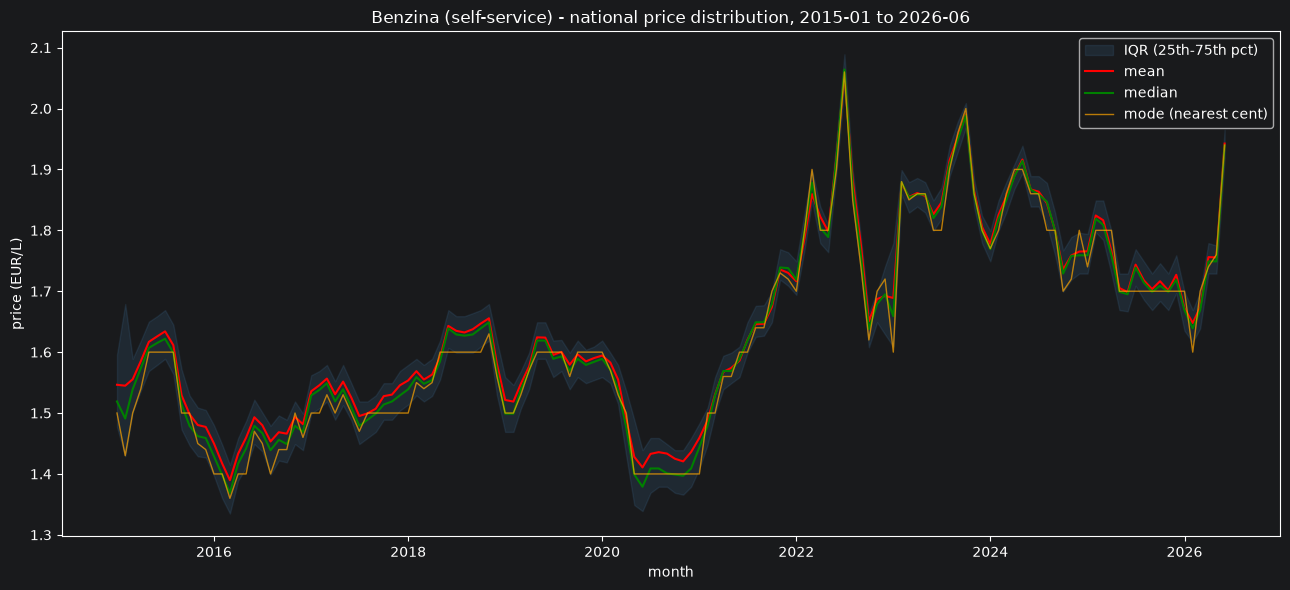

In [10]:
fig, ax = plt.subplots(figsize=(13, 6))

ax.fill_between(good['month'], good['p25'], good['p75'],
                alpha=0.15, color='steelblue', label='IQR (25th-75th pct)')
ax.plot(good['month'], good['mean_price'], color='red', label='mean')
ax.plot(good['month'], good['median_price'], color='green', label='median')
ax.plot(good['month'], good['mode_price'], color='orange', linewidth=1,
        alpha=0.7, label='mode (nearest cent)')

ax.set_xlabel('month')
ax.set_ylabel('price (EUR/L)')
ax.set_title(f'{FUEL} ({"self-service" if SELF_SERVICE else "full-service"}) '
             f'- national price distribution, {good["month"].min():%Y-%m} to {good["month"].max():%Y-%m}')
ax.legend()
plt.tight_layout()
plt.show()

### Is the mean ever unrepresentative?

This notebook's original question was whether the published mean gets pulled away
from what most stations actually charge. Plotting `mean - median` over time
answers it directly: near zero means a symmetric distribution the mean summarises
fairly; a sustained gap would mean real skew.

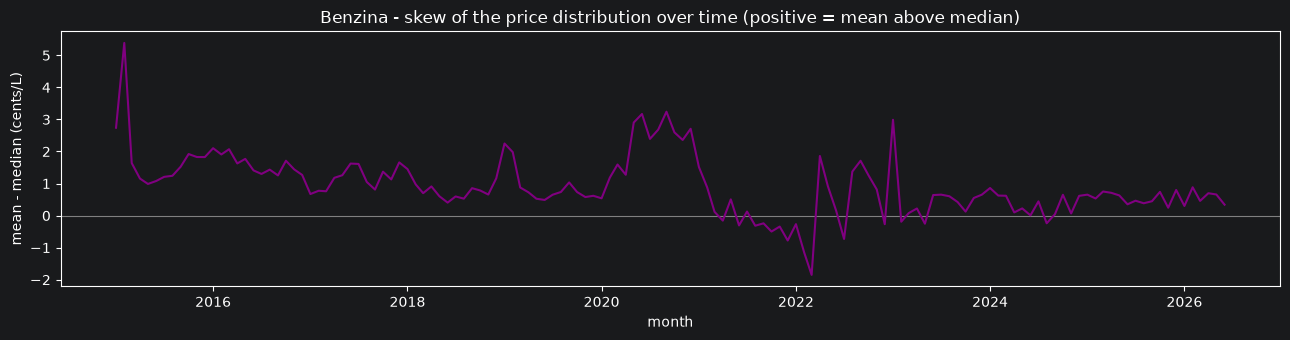

count    138.000000
mean       0.927913
std        0.938607
min       -1.850923
25%        0.450251
50%        0.745348
75%        1.400274
max        5.387148
dtype: float64

In [11]:
gap = (good['mean_price'] - good['median_price']) * 100  # cents/L

fig, ax = plt.subplots(figsize=(13, 3.5))
ax.axhline(0, color='grey', linewidth=0.8)
ax.plot(good['month'], gap, color='purple')
ax.set_xlabel('month')
ax.set_ylabel('mean - median (cents/L)')
ax.set_title(f'{FUEL} - skew of the price distribution over time (positive = mean above median)')
plt.tight_layout()
plt.show()

gap.describe()

## Does the mean stay representative?

Across the 136 usable months the mean tracks the median remarkably closely - the
gap is under 1.5 cents/L three-quarters of the time, and in the calm 2023-2025
stretch it averages just 0.4 cents. The mean sits *very slightly* above the
median in most months: the mild, persistent right skew from the thin tail of
expensive stations (motorway, premium brands) seen in the snapshot above. It is
nowhere near enough to make the published national average misleading.

The distribution only skews meaningfully during periods of rapid price change,
and the direction depends on which way prices are moving:

- **Sharp drops** pull the mean *above* the median (right skew): the COVID
  demand collapse in spring/summer 2020 opened a ~3-4 cent gap as quick-moving
  discounters cut first and slower stations trailed on the high side.
- **Sharp spikes** pull the mean *below* the median (left skew): the invasion of
  Ukraine in March 2022 produced a -5.5 cent gap - the largest in the series -
  as stations that had not yet repriced sat as a low tail beneath a
  rapidly-rising median.

Both are transient, resolving within a month or two once stations finish
adjusting. So the published mean is a fair summary of the national price except
in the immediate aftermath of a shock - when no single number describes a
distribution that is genuinely spread out and mid-adjustment.